## Sales Performance Analytics

Author - Abhinav Srivastava

Last Updated - 01-May-2026

**Meta-Data** of the Sales Dataset:

The dataset contains quarterly sales performance of an Apparel company in Q4 2025

Importing required packages

*  NumPy - for data manipulation.
*  Pandas - for data manipulation.
*  MatPlotLib - for data visualization.
*  Seaborn - for data visualization.
*  DateTime - for date and time manipulation  

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, time, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = 'whitegrid')
%matplotlib inline
pd.set_option('display.max_rows', None)

Reading the dataset

In [ ]:
saledf = pd.read_csv('Aus_Apparal_Sales_Q4_2025.csv')
saledf.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


### 1. Data Wrangling

Ensure that the data is clean and free from any missing or incorrect entries. 

For this, first we need to have a rough idea of dataset. Checking for shape (i.e. - dimensions of dataset) and column info.

In [10]:
saledf.shape, saledf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


((7560, 6), None)

Next, need to check for missing values in the data. If any, will be required to handled.

In [ ]:
# Task 1-a

#saledf[saledf.isna().any(axis = 1)]
print('Missing values - ')
saledf.isna().sum()
print('Non-missing values - ')
saledf.notna().sum()

Missing values - 
Non-missing values - 


Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Since no missing values encountered, we will move to other checks in our data cleaning process.

Next, treating missing and incorrect data

Here, assigning mean of non-null values to the null fields

In [ ]:
saledf.dropna(how = 'all', inplace = True)

saledf['Sales'] = saledf['Sales'].fillna(saledf['Sales'].mean())

Data normalisation on 'Sales' and 'Unit'

Why? If 'Sales' is in thousands (e.g. 50,000) and 'Unit' is small (e.g. 5), algorithms treat 'Sales' as far more "important" simply due to magnitude — not actual relevance.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

saledf[['Sales', 'Unit']] = scaler.fit_transform(saledf[['Sales', 'Unit']])
saledf[['Sales', 'Unit']].head(10)

,Sales,Unit
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873
5,0.126984,0.126984
6,0.015873,0.015873
7,0.142857,0.142857
8,0.206349,0.206349
9,0.206349,0.206349


State-wise sales overview

In [ ]:
saledf.groupby('State')['Sales'].sum().sort_values(ascending = False)

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64

### 2. Data Analysis

Descriptive Statistical Analysis

In [ ]:
print(saledf[['Sales', 'Unit']].describe())
print(saledf[['Sales', 'Unit']].mode())

             Sales         Unit
count  7560.000000  7560.000000
mean      0.254054     0.254054
std       0.204784     0.204784
min       0.000000     0.000000
25%       0.095238     0.095238
50%       0.190476     0.190476
75%       0.380952     0.380952
max       1.000000     1.000000
      Sales      Unit
0  0.111111  0.111111


Identification of groups with highest and lowest sales

In [ ]:

top_sales_gp = saledf.groupby('Group')['Sales'].sum().idxmax()
min_sales_gp = saledf.groupby('Group')['Sales'].sum().idxmin()
print(f"Group with highest sales: {top_sales_gp}")
print(f"Group with lowest sales: {min_sales_gp}")

Group with highest sales:  Men
Group with lowest sales:  Seniors


Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.

In [ ]:

saledf['Date'] = pd.to_datetime(saledf['Date'])
saledf['week'] = saledf['Date'].dt.isocalendar().week
saledf['month'] = saledf['Date'].dt.month
saledf['quarter'] = saledf['Date'].dt.quarter
saledf.head()

,Date,Time,State,Group,Unit,Sales,week,month,quarter
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,40,10,4
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,40,10,4
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,40,10,4
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,40,10,4
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,40,10,4


In [95]:
weekly_sales = saledf.groupby('week')['Sales'].sum().reset_index()
monthly_sales = saledf.groupby('month')['Sales'].sum().reset_index()
quarterly_sales = saledf.groupby('quarter')['Sales'].sum().reset_index()
print(f"Weekly Sales: {weekly_sales}")
print(f"Monthly Sales: {monthly_sales}")
print(f"Quarterly Sales: {quarterly_sales}")


Weekly Sales:     week       Sales
0     40   84.857143
1     41  152.777778
2     42  150.476190
3     43  151.587302
4     44  122.460317
5     45  113.809524
6     46  115.761905
7     47  115.380952
8     48  117.698413
9     49  169.412698
10    50  181.492063
11    51  182.317460
12    52  183.047619
13    53   79.571429
Monthly Sales:    month       Sales
0     10  645.650794
1     11  495.761905
2     12  779.238095
Quarterly Sales:    quarter        Sales
0        4  1920.650794


### 3. Data Visualisation

State-wise sales analysis for different demographic groups (kids, 
women, men, and seniors)

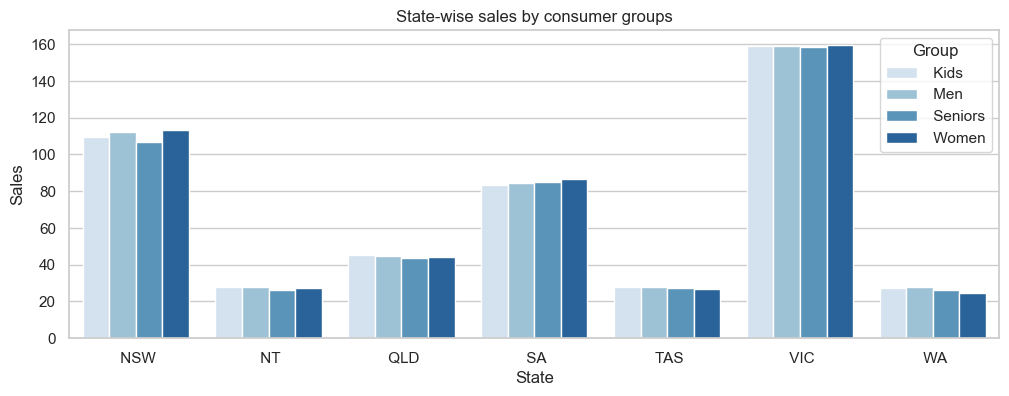

In [ ]:

statewise_sales = saledf.groupby(['State', 'Group'])['Sales'].sum().reset_index()
plt.figure(figsize = (12,4))
sns.barplot(data = statewise_sales, x = 'State', y = 'Sales', hue = 'Group', palette = 'Blues')
plt.title('State-wise sales by consumer groups')
plt.show()

# saledf.groupby(['Group', 'State'])['Sales'].sum().reset_index()



Group-wise sales analysis (Kids, Women, Men, and Seniors) across 
various states

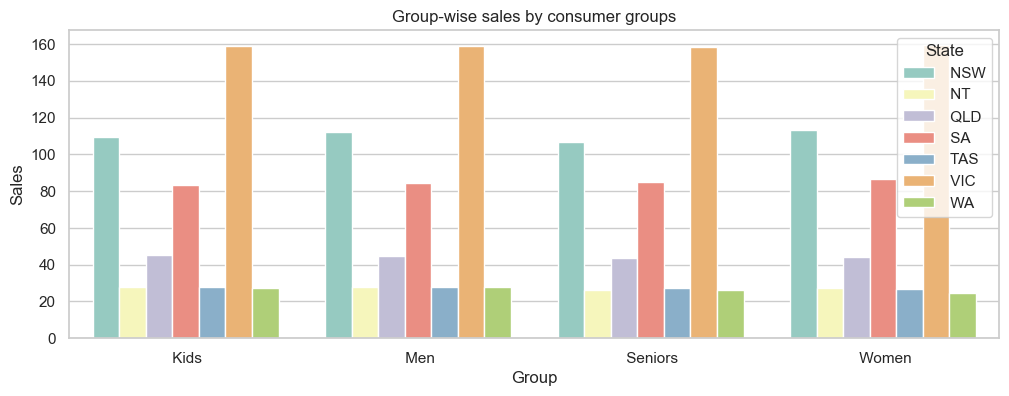

In [ ]:

groupwise_sales = saledf.groupby(['Group', 'State'])['Sales'].sum().reset_index()
plt.figure(figsize = (12,4))
sns.barplot(data = groupwise_sales, x = 'Group', y = 'Sales', hue = 'State', palette = 'Set3')
plt.title('Group-wise sales by consumer groups')
plt.show()

Time-of-the-day analysis: 

Identification of peak and off-peak sales periods to 
facilitate strategic planning for S&M teams. This information aids in 
designing programs like hyper-personalization and Next Best Offers to 
enhance sales.

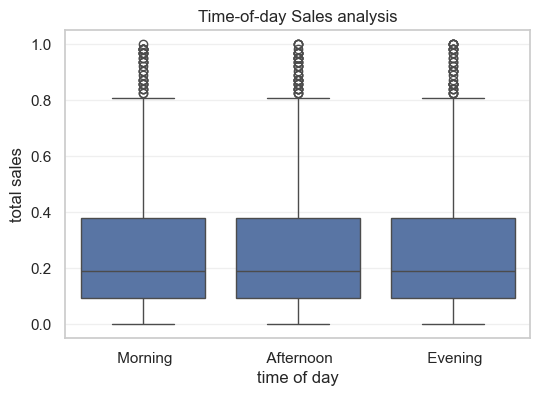

In [87]:
# Task 3-a(3)

plt.figure(figsize = (6,4))
sns.boxplot(data = saledf, x = 'Time', y = 'Sales')
plt.title('Time-of-day Sales analysis')
plt.xlabel('time of day')
plt.ylabel('total sales')
plt.grid(alpha = 0.3, axis = 'y')
plt.show()


### Dashboard creation for reporting purposes, and sharing with S&M teams 

Daily sales trend

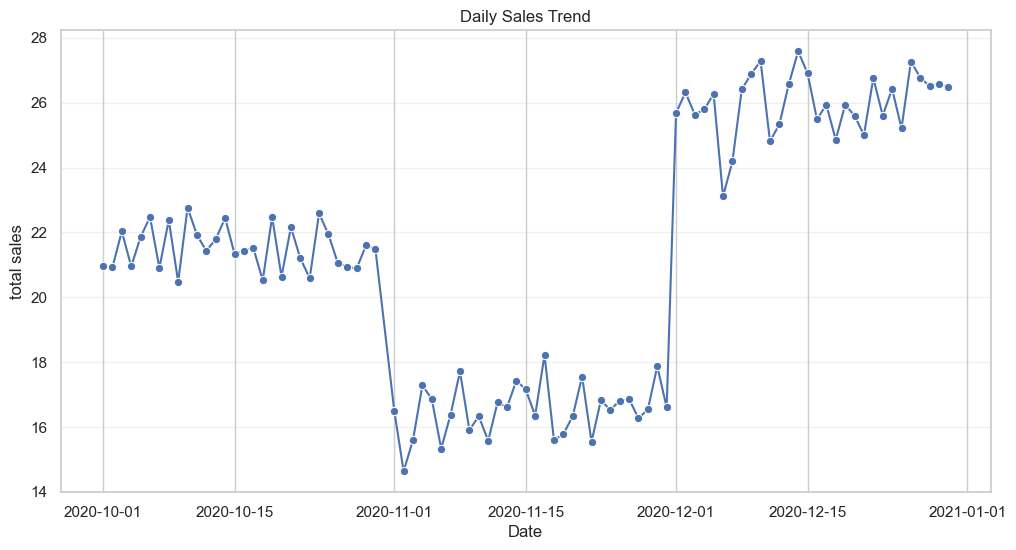

In [ ]:

daily_sales = saledf.groupby('Date')['Sales'].sum().reset_index()
plt.figure(figsize = (12,6))
sns.lineplot(data = daily_sales, x = 'Date', y = 'Sales', marker = 'o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('total sales')
plt.grid(alpha = 0.3, axis = 'y')
plt.show()

Weekly sales trend

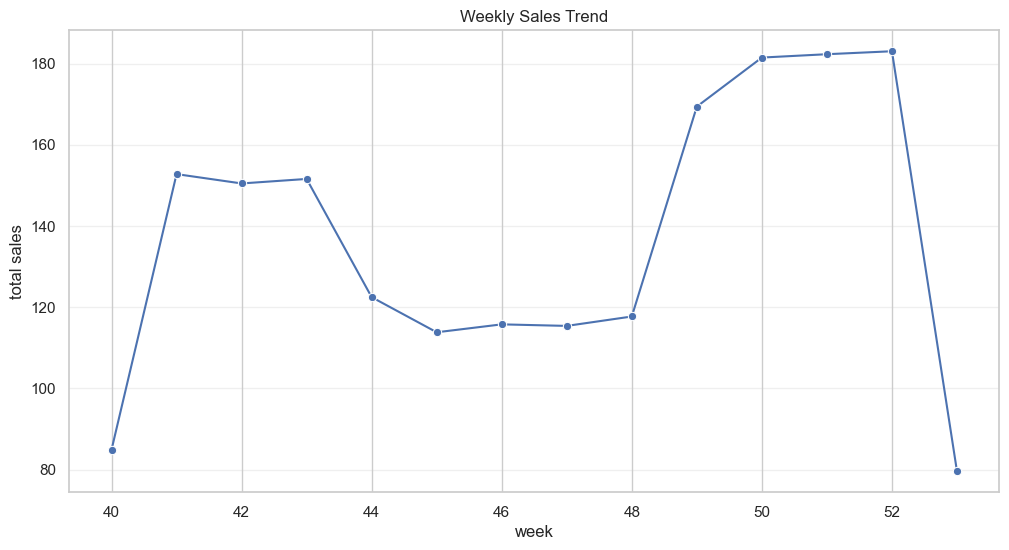

In [ ]:

plt.figure(figsize = (12,6))
sns.lineplot(data = weekly_sales, x = 'week', y = 'Sales', marker = 'o')
plt.title('Weekly Sales Trend')
plt.xlabel('week')
plt.ylabel('total sales')
plt.grid(alpha = 0.3, axis = 'y')
plt.show()

Monthly sales trend

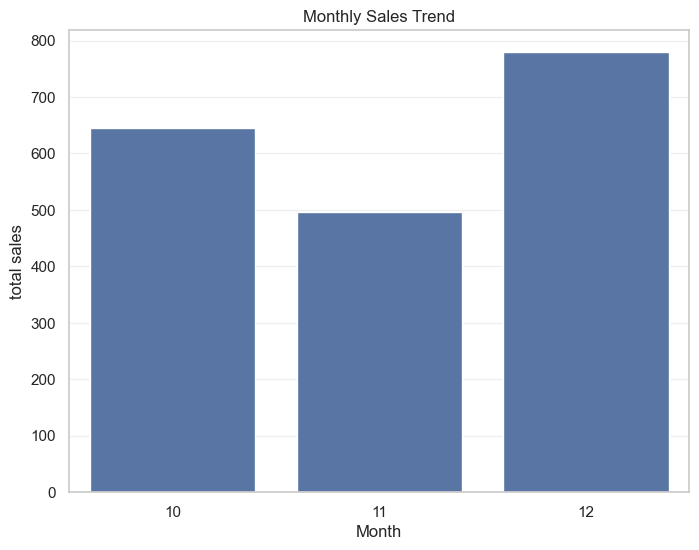

In [ ]:

plt.figure(figsize = (8,6))
sns.barplot(data = monthly_sales, x = 'month', y = 'Sales')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('total sales')
plt.grid(alpha = 0.3, axis = 'y')
plt.show()

Quarterly sales trend

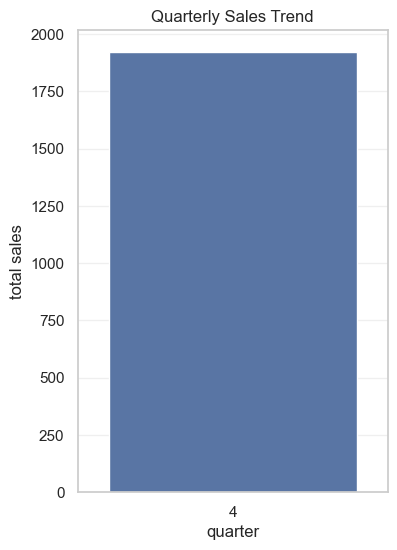

In [ ]:

plt.figure(figsize = (4,6))
sns.barplot(data = quarterly_sales, x = 'quarter', y = 'Sales')
plt.title('Quarterly Sales Trend')
plt.xlabel('quarter')
plt.ylabel('total sales')
plt.grid(alpha = 0.3, axis = 'y')
plt.show()


Recommendation – Visualization Package

For this project, the recommended visualization package is Seaborn.

Reason:

Seaborn is built on top of Matplotlib and provides:

* Clean and professional plots with minimal code.

* Better support for statistical visualizations (bar plots, box plots, line plots).

* Readable styles and built-in themes, making the charts clear for business dashboards.

Therefore, Seaborn is the preferred choice for building the sales analysis dashboard in this project.

### 4. Report Generation

In [2]:

report = """

Sales Analysis Report (Q4)

1. State-wise Sales Analysis:

- Top states: VIC

- Lowest performing states: WA

2. Sales Distribution by Group:

- Highest sales category: Men

- Lowest sales category: Seniors

3. Sales Trends:

- Daily: Sales fluctuations throughout Q4

- Weekly: Identified high and low sales weeks

- Monthly: Sales trends for each month in Q4

- Quarterly: Overall Q4 sales comparison by state

Recommendations:

- Optimize inventory for peak hours

- Improve marketing strategies in low-sales states

- Leverage Q4 sales trends for better promotions

"""

print(report)



Sales Analysis Report (Q4)

1. State-wise Sales Analysis:

- Top states: VIC

- Lowest performing states: WA

2. Sales Distribution by Group:

- Highest sales category: Men

- Lowest sales category: Seniors

3. Sales Trends:

- Daily: Sales fluctuations throughout Q4

- Weekly: Identified high and low sales weeks

- Monthly: Sales trends for each month in Q4

- Quarterly: Overall Q4 sales comparison by state

Recommendations:

- Optimize inventory for peak hours

- Improve marketing strategies in low-sales states

- Leverage Q4 sales trends for better promotions


